### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [148]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.utils.multiclass import type_of_target

In [112]:
from xgboost import XGBRegressor
from imblearn.over_sampling import RandomOverSampler
from feature_engine.selection import SmartCorrelatedSelection
from feature_engine.outliers import ArbitraryOutlierCapper

### Step 2: Load Data

In [4]:
df = pd.read_csv('./data/insurance.csv')

In [5]:
df.shape

(1338, 7)

In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Step 3: Exploaring Data

Basic Info

In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [12]:
pd.DataFrame({'Null': df.isnull().sum(), 'Unique': df.nunique(), 'Dtype': df.dtypes})

,Null,Unique,Dtype
age,0,47,int64
sex,0,2,object
bmi,0,548,float64
children,0,6,int64
smoker,0,2,object
region,0,4,object
charges,0,1337,float64


In [73]:
df.select_dtypes(np.number).skew()

age         0.055673
bmi         0.284047
children    0.938380
charges     1.515880
dtype: float64

Target Distribution

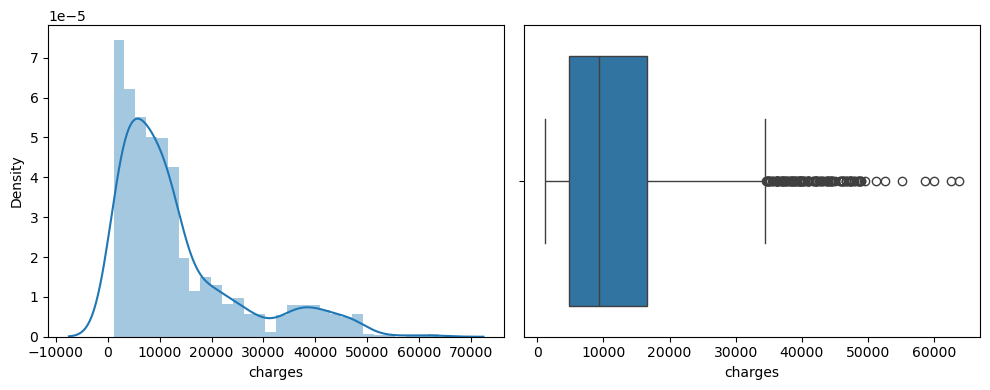

In [23]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.distplot(df['charges'])
plt.subplot(1, 2, 2)
sns.boxplot(df['charges'], orient='h')
plt.tight_layout()

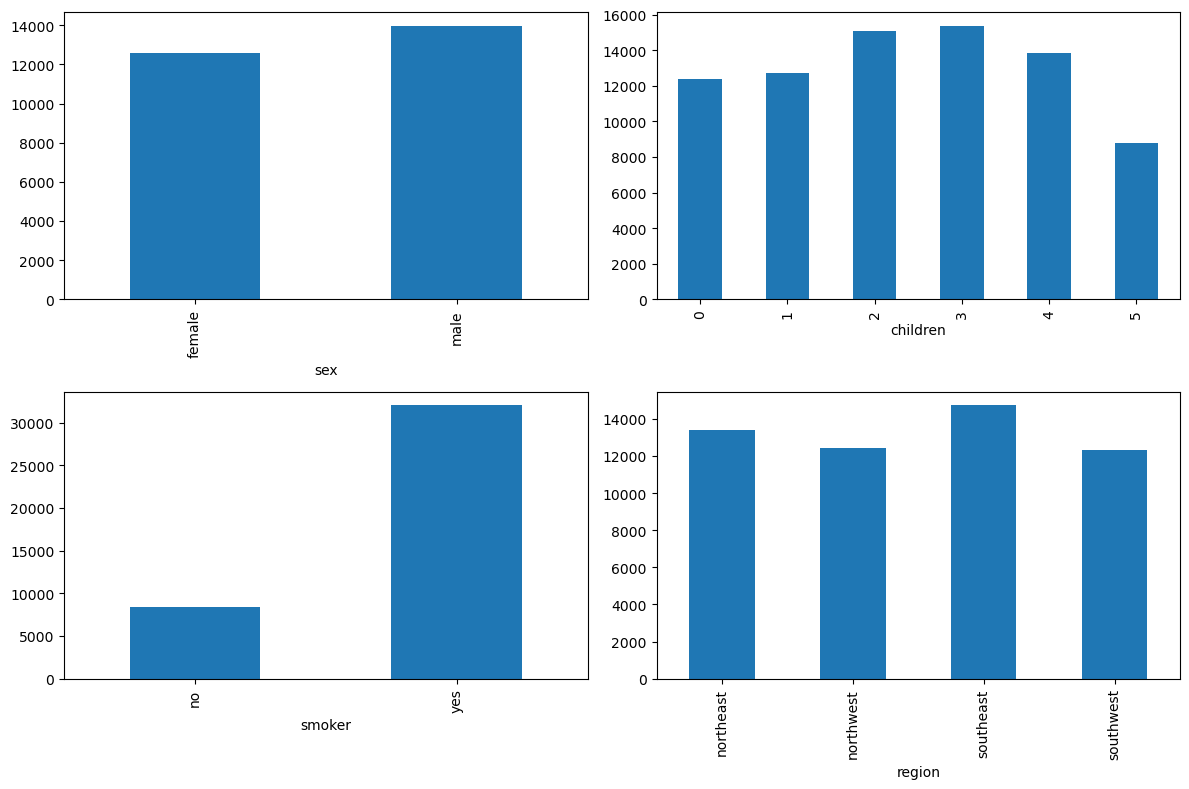

In [53]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(['sex', 'children', 'smoker', 'region']):
    plt.subplot(2, 2, i + 1)
    df.groupby(col)['charges'].mean().astype(float).plot.bar()
plt.tight_layout()

Int Distribution

In [25]:
int_cols = df.select_dtypes(np.int64).columns.to_list()
print(f'int type number: {len(int_cols)}')

int type number: 2


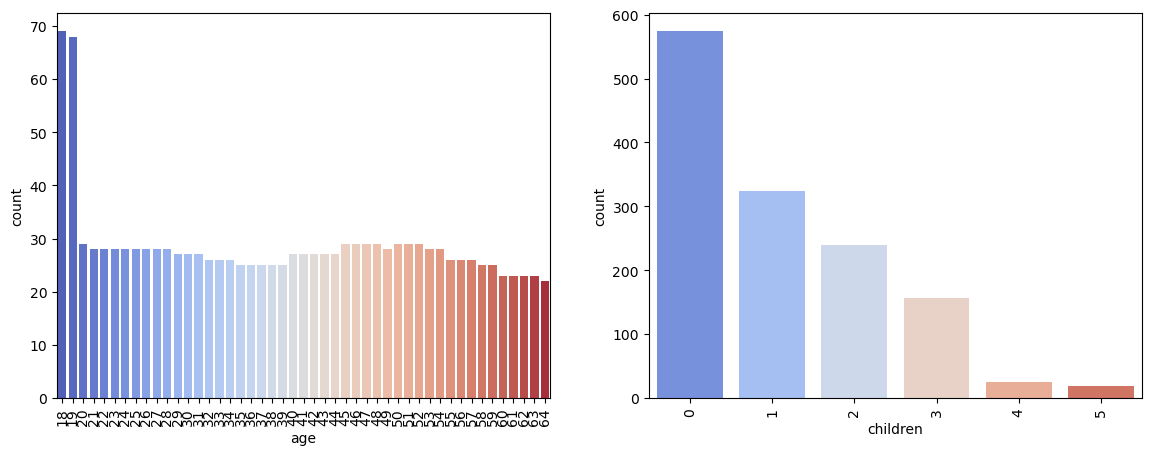

In [43]:
plt.figure(figsize=(14, 5))
for i, col in enumerate(int_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(
        x=col,
        data=df,
        palette='coolwarm'
    )
    plt.xticks(rotation=90)

Float Distribution

In [36]:
float_cols = df.select_dtypes(np.float_).columns.to_list()

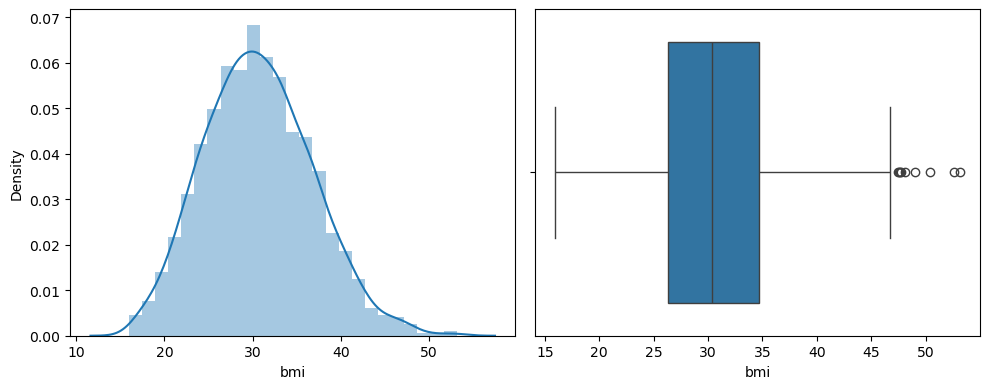

In [44]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.distplot(df['bmi'])
plt.subplot(1, 2, 2)
sns.boxplot(df['bmi'], orient='h')
plt.tight_layout()

Object Distribution

In [45]:
obj_cols = df.select_dtypes(np.object_).columns.to_list()

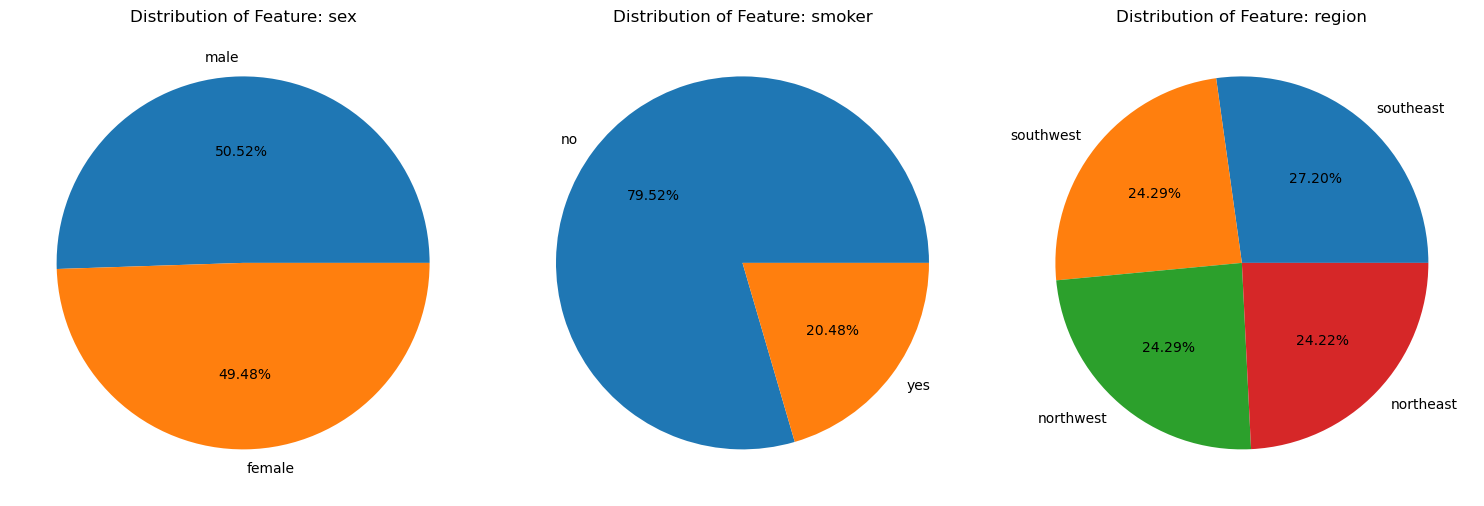

In [49]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(obj_cols):
    plt.subplot(1, 3, i+1)
    x = df[col].value_counts()
    plt.pie(
        x,
        labels=x.index,
        autopct='%.2f%%'
    )
    plt.title(f'Distribution of Feature: {col}')
plt.tight_layout()

Other Feature Distribution

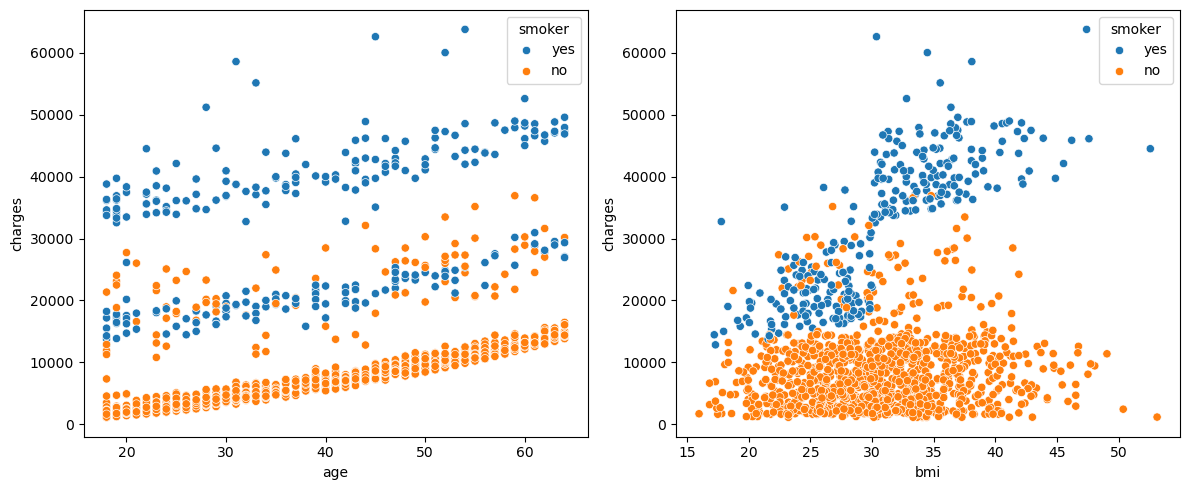

In [61]:
plt.figure(figsize=(12, 5))
for i, col in enumerate(['age', 'bmi']):
    plt.subplot(1, 2, i+1)
    sns.scatterplot(
        x=col,
        y='charges',
        hue='smoker',
        data=df
    )
plt.tight_layout()

### Step 4: Feature Engineering

Handling Missing Value

In [64]:
df.dropna(inplace=True)

Feature Encoding

In [76]:
for col in obj_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

Heat Map

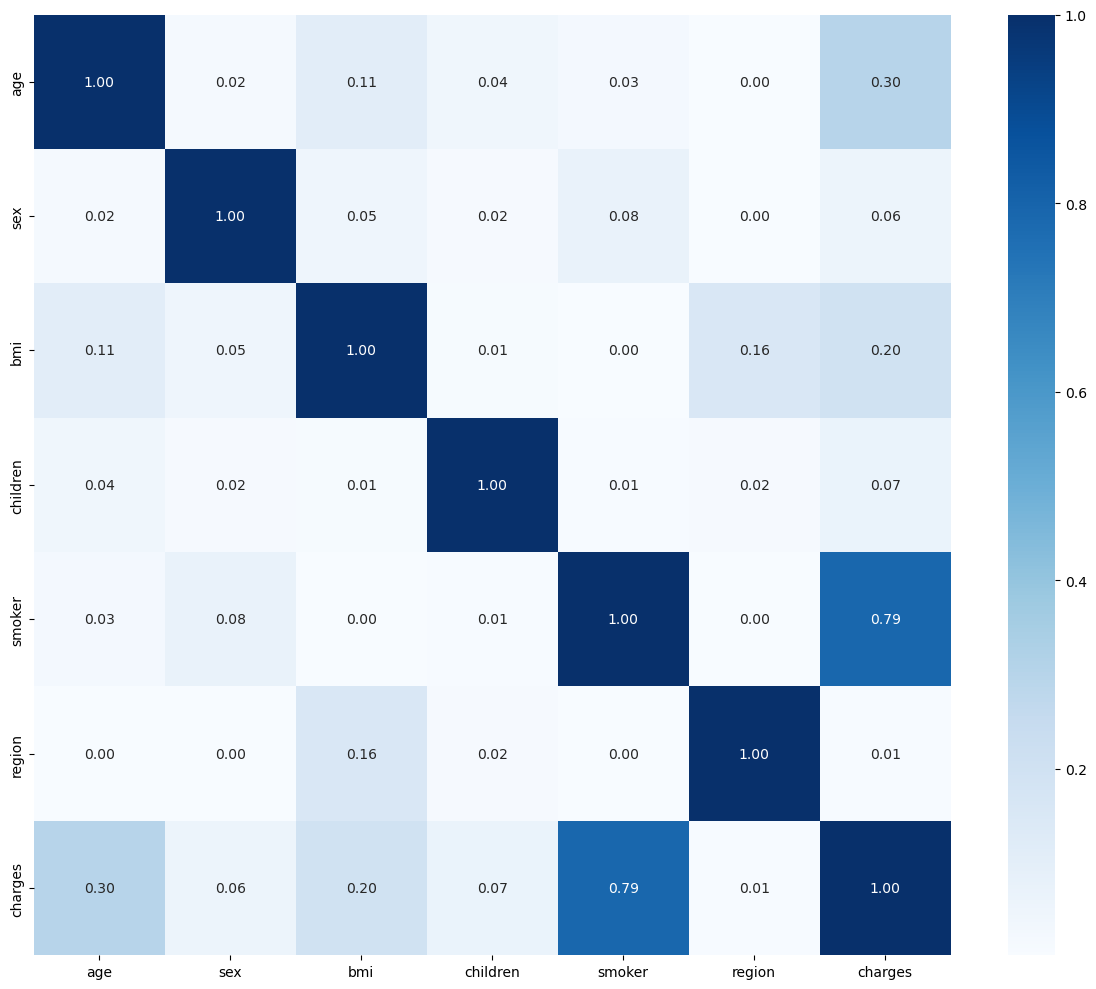

In [79]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.corr().abs(),
    fmt='.2f',
    annot=True,
    cmap=plt.cm.Blues
)
plt.tight_layout()

### Step 5: Preparing Data

Select Features

In [80]:
features = df.drop('charges', axis=1)
target = df['charges']

In [81]:
selector = SmartCorrelatedSelection(
    threshold=0.8,
    selection_method='corr_with_target'
)

In [82]:
features = selector.fit_transform(features, target)

In [83]:
print(f'Current Number of Features is {features.shape[1]}')

Current Number of Features is 6


Split Data

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

Handling Outlier

In [90]:
def iqr_bounds(series, k=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

In [91]:
lowlim, upplim = iqr_bounds(X_train['bmi'])

In [92]:
arb = ArbitraryOutlierCapper(
    min_capping_dict={'bmi': lowlim},
    max_capping_dict={'bmi': upplim}
)

In [97]:
X_train['bmi'] = arb.fit_transform(X_train[['bmi']])

Normalization

In [98]:
scaler = StandardScaler()

In [106]:
X_train = scaler.fit_transform(X_train)

In [110]:
X_train = pd.DataFrame(X_train, columns=X_test.columns)

In [144]:
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

### Step 6: Building & Training Model

In [136]:
models = [
    SVR(),
    RandomForestRegressor(),
    GradientBoostingRegressor(),
    XGBRegressor(),
    LinearRegression(),
]

In [137]:
for model in models:
    print(f"Model: {model.__class__.__name__}")
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        n_jobs=-1,
        error_score='raise'
    )
    print(f'r2 Scores: {list(map(lambda x: round(x, 3), scores))}')
    print(f'r2: {scores.mean():.3f}')
    print('-' * 20)

Model: SVR
r2 Scores: [-0.108, -0.164, -0.069, -0.1, -0.049]
r2: -0.098
--------------------
Model: RandomForestRegressor
r2 Scores: [0.816, 0.902, 0.791, 0.776, 0.833]
r2: 0.824
--------------------
Model: GradientBoostingRegressor
r2 Scores: [0.832, 0.921, 0.816, 0.791, 0.841]
r2: 0.840
--------------------
Model: XGBRegressor
r2 Scores: [0.777, 0.864, 0.769, 0.741, 0.817]
r2: 0.794
--------------------
Model: LinearRegression
r2 Scores: [0.716, 0.803, 0.726, 0.66, 0.767]
r2: 0.734
--------------------


In [138]:
for model in models:
    model.fit(X_train, y_train)

### Step 7: Evaluate Model

Accuracy

In [145]:
for model in models:
    y_pred = model.predict(X_test)
    print(f'Model: {model.__class__.__name__}')
    print('Training r2 : ', round(metrics.r2_score(y_train, model.predict(X_train)), 3))
    print('Validation r2 : ', round(metrics.r2_score(y_test, y_pred), 3))
    print('-' * 20)

Model: SVR
Training r2 :  -0.093
Validation r2 :  -0.068
--------------------
Model: RandomForestRegressor
Training r2 :  0.976
Validation r2 :  0.868
--------------------
Model: GradientBoostingRegressor
Training r2 :  0.898
Validation r2 :  0.878
--------------------
Model: XGBRegressor
Training r2 :  0.994
Validation r2 :  0.85
--------------------
Model: LinearRegression
Training r2 :  0.742
Validation r2 :  0.783
--------------------


### Step 8: Analysis Model

Random Forest Regressor

In [171]:
estimator = RandomForestRegressor(random_state=42)

In [172]:
param_grid = {'n_estimators': [10, 40, 50, 98, 100, 120, 150]}

In [173]:
grid = GridSearchCV(
    estimator,
    param_grid,
    scoring="r2",
    cv=5
)

In [174]:
grid.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'n_estimators': [10, 40, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,40


In [175]:
print(grid.best_params_)

{'n_estimators': 40}


In [176]:
pred_train = grid.best_estimator_.predict(X_train)
pred_test = grid.best_estimator_.predict(X_test)

In [177]:
print('Train r2:', round(metrics.r2_score(y_train, pred_train), 3))
print('Test r2:', round(metrics.r2_score(y_test, pred_test), 3))

Train r2: 0.972
Test r2: 0.866


Gradient Boosting Regressor

In [190]:
estimator = GradientBoostingRegressor()

In [191]:
param_grid = {
    'n_estimators': [10, 15, 19, 20, 21, 50],
    'learning_rate': [0.1, 0.19, 0.2, 0.21, 0.8, 1]
}

In [192]:
grid = GridSearchCV(
    estimator,
    param_grid,
    scoring='r2',
    cv=5
)

In [193]:
grid.fit(X_train, y_train)

,estimator,GradientBoostingRegressor()
,param_grid,"{'learning_rate': [0.1, 0.19, ...], 'n_estimators': [10, 15, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [194]:
print(grid.best_params_)

{'learning_rate': 0.19, 'n_estimators': 19}


In [195]:
pred_train = grid.best_estimator_.predict(X_train)
pred_test = grid.best_estimator_.predict(X_test)

In [196]:
print('Train r2:', round(metrics.r2_score(y_train, pred_train), 3))
print('Test r2:', round(metrics.r2_score(y_test, pred_test), 3))

Train r2: 0.876
Test r2: 0.878


XGBRegressor

In [197]:
estimator = XGBRegressor()

In [198]:
param_grid = {
    'n_estimators': [10,15,20,40,50],
    'max_depth': [3,4,5],
    'gamma': [0,0.15,0.3,0.5,1]
}

In [199]:
grid = GridSearchCV(
    estimator,
    param_grid,
    scoring='r2',
    cv=5
)

In [200]:
grid.fit(X_train, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'gamma': [0, 0.15, ...], 'max_depth': [3, 4, ...], 'n_estimators': [10, 15, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [201]:
print(grid.best_params_)

{'gamma': 0, 'max_depth': 3, 'n_estimators': 10}


In [202]:
pred_train = grid.best_estimator_.predict(X_train)
pred_test = grid.best_estimator_.predict(X_test)

In [203]:
print('Train r2:', round(metrics.r2_score(y_train, pred_train), 3))
print('Test r2:', round(metrics.r2_score(y_test, pred_test), 3))

Train r2: 0.871
Test r2: 0.881


In [204]:
pd.DataFrame(
    data=grid.best_estimator_.feature_importances_,
    index=X_train.columns,
    columns=['Importance']
)

,Importance
age,0.039085
sex,0.003593
bmi,0.127769
children,0.010264
smoker,0.814090
region,0.005199


In [207]:
features_new = features.drop(['sex', 'region'], axis=1)

In [210]:
X_train, X_test, y_train, y_test = train_test_split(
    features_new,
    target,
    test_size=0.2,
    random_state=42
)

In [211]:
scaler = StandardScaler()

In [212]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [214]:
model_best = XGBRegressor(
    n_estimators=15,
    max_depth=3,
    gamma=0
)

In [215]:
model_best.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [216]:
pred_train = model_best.predict(X_train)
pred_test = model_best.predict(X_test)

In [217]:
print('Train r2:', round(metrics.r2_score(y_train, pred_train), 3))
print('Test r2:', round(metrics.r2_score(y_test, pred_test), 3))

Train r2: 0.877
Test r2: 0.885


### Step 9: Model Prediction

In [218]:
new_data=pd.DataFrame(
    {
        'age':19,
        'bmi':27.9,
        'children':0,
        'smoker':1,
    }, index=[0]
)

In [220]:
new_data = scaler.transform(new_data)

In [221]:
model_best.predict(new_data)

array([17876.135], dtype=float32)